# Chunking: Build the chunks for the two training dataset IHC and ISHate

This notebook assembles all the training text chunks that will go into the FAISS retrieval index.
It add IHC and ISHate chunks into `chunks/chunks_IHC.csv` and `chunks/chunks_ISHate.csv`.
Then add the same ones into the full chunk file `chunks/chunks.csv` consumed by the next notebook (`index.ipynb`).

**Sources**
- IHC training examples (loaded from HuggingFace, `post` column)
- ISHate training examples (loaded from HuggingFace, `text` column)

**Output CSV schema:**

chunk_id | text
---------|-------------------------------
0        | [hate] you are all subhuman
1        | [not hate] I love this city


The labels are written into the `text` field, no data leakage is possible : for the model training, we mask the input using the chunk_id (or index_id) and for testing, no test examples are integrated into the chunk file.

## 1. Imports
Different classical librairies are used **to operate** on the datasets (pandas, numpy, matplotlib).  
The librairies datasets and huggingface_hub are used to **load the datasets**.  
And transformers librairy to be able to **import the model's tokenizers**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer

## 2. Load the datasets

### a. IHC training data

Dataset: `tasksource/implicit-hate-stg1`  
Text column: `post`  
Label column: `class` → `not_hate` maps to `not_hate`, everything else (implicit, explicit) maps to `hate`

Only the **training split** is used (90/10 split with seed=42, same as baseline notebook).  
The test split is reserved for inference queries only.

In [2]:
# Full dataset from the IHC, lines are an entry, columns are a feature like post (the text), class (hate/non-hate), ...
ihc_ds = load_dataset("tasksource/implicit-hate-stg1", split="train")
print("Length of the full dataset : ", len(ihc_ds))

# Reproduce the same 90/10 split as baseline.ipynb (seed=42) to load only the training data
ihc_train = ihc_ds.train_test_split(test_size=0.10, seed=42)["train"]
print("Length of the training dataset : ", len(ihc_train))

# Converting the same time implicit/explicite hate
ihc_chunks = []
for row in ihc_train:
    label = "not_hate" if row["class"] == "not_hate" else "hate"
    ihc_chunks.append({"text": row["post"], "label": label})

print(f"IHC training examples: {len(ihc_chunks)}")
print("Examples of the data we have:")
for i in range(5):
    print(ihc_chunks[i+5])

README.md:   0%|          | 0.00/792 [00:00<?, ?B/s]

implicit_hate_v1_stg1_posts.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/21480 [00:00<?, ? examples/s]

Length of the full dataset :  21480
Length of the training dataset :  19332


IHC training examples: 19332
Examples of the data we have:
{'text': '. help biafrans get freedom and independence . please save biafrans from murderous nigeria terrorists', 'label': 'hate'}
{'text': 'you should dead  racist  motherfuckersthis is ku klux klan', 'label': 'hate'}
{'text': "we're all vertebrates too . except for cucks .", 'label': 'hate'}
{'text': 'white people are not alowed to have opinions if we do we are so bad', 'label': 'not_hate'}
{'text': "how the dynasty turned large chunks of lutyens ' delhi into private property", 'label': 'not_hate'}


### b. ISHate training data

Dataset: `BenjaminOcampo/ISHate`  
Text column: `text`  
Label column: `hateful_layer` → `Non-HS` maps to `not_hate`, everything else maps to `hate`

Uses the pre-made train split directly as in baseline notebook.

In [3]:
# Load directly only the training data via ishate_train.parquet.gzip
ishate_path = hf_hub_download(repo_id="BenjaminOcampo/ISHate", filename="ishate_train.parquet.gzip", repo_type="dataset")
ishate_df = pd.read_parquet(ishate_path)
print("Length of the training dataset : ", len(ishate_df))

# Converting the same time implicit/explicite hate
ishate_chunks = []
for _, row in ishate_df.iterrows():
    label = "not_hate" if row["hateful_layer"] == "Non-HS" else "hate"
    ishate_chunks.append({"source": "ishate_train", "text": row["text"], "label": label})

print(f"ISHate training examples: {len(ishate_chunks)}")
print("Examples of the data we have:")
for i in range(5):
    print(ishate_chunks[i+5])

ishate_train.parquet.gzip:   0%|          | 0.00/3.45M [00:00<?, ?B/s]

Length of the training dataset :  55023


ISHate training examples: 55023
Examples of the data we have:
{'source': 'ishate_train', 'text': "fuk that I burned a qu'ran and pissed on it...", 'label': 'hate'}
{'source': 'ishate_train', 'text': 'You left me in the dark for some bitch that had a kid while you were in the pin but yet you still chose that dry cunt over your son how sad.', 'label': 'not_hate'}
{'source': 'ishate_train', 'text': 'An Illegal Alien took his own life because he decide he would break into the U.S Steal IDs and SSN to Work Illegally Robbing the U.S instead of sending for his family he killed himself Really didnt care about his Family huh ? #SendthemBack #Immigration', 'label': 'hate'}
{'source': 'ishate_train', 'text': '@MailOnline Bloody Germany who needs Germany we dont want their Visa plans were are fed up of being over ran by migrants no Uk Jobs threaten', 'label': 'hate'}
{'source': 'ishate_train', 'text': 'Immigrants are not welcome here, and should not mix with us.', 'label': 'hate'}


### c. Vicomtech training data

Dataset: local clone at `../data/hate-speech-dataset` (git submodule — https://github.com/Vicomtech/hate-speech-dataset)  
Labels: `hate` → `hate`, `noHate` → `not_hate`; `idk/skip` and `relation` rows are discarded.  
Split: `sampled_train/` directory.

In [4]:
DATA_DIR = "../data/hate-speech-dataset"
split_dir = os.path.join(DATA_DIR, "sampled_train")

vico_meta = pd.read_csv(os.path.join(DATA_DIR, "annotations_metadata.csv")).set_index("file_id")

vicomtech_chunks = []
for fname in sorted(os.listdir(split_dir)):
    if not fname.endswith(".txt"):
        continue
    file_id = fname.replace(".txt", "")
    if file_id not in vico_meta.index:
        continue
    label_str = vico_meta.loc[file_id, "label"]
    if label_str in ("idk/skip", "relation"):
        continue
    with open(os.path.join(split_dir, fname), encoding="utf-8") as fh:
        text = fh.read().strip()
    if not text:
        continue
    label = "hate" if label_str == "hate" else "not_hate"
    vicomtech_chunks.append({"text": text, "label": label})

print(f"Vicomtech training examples: {len(vicomtech_chunks)}")
for row in vicomtech_chunks[:5]:
    print(row)

Vicomtech training examples: 1914
{'text': 'In order to help increase the booklets downloads , it would be great if all Stormfronters who had YouTube accounts , could display the following text in the description boxes of their uploaded YouTube videos .', 'label': 'not_hate'}
{'text': 'Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .', 'label': 'hate'}
{'text': 'Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .', 'label': 'hate'}
{'text': 'Booklet updated on Dec. 9th , 2013 .', 'label': 'not_hate'}
{'text': "Thank you in advance. : ) Download the youtube `` description box '' info text file below @ http://www.mediafire.com/download/gxv2b33v37la6pz/Booklet % 20Description % 20Box % 20Info.txt", 'label': 'not_hate'}


## 3. Deduplication

Both datasets contain duplicate samples at two levels:
- **Within each dataset:** Some texts appear multiple times in IHC or in ISHate separately
- **Across datasets:** Some identical texts appear in both IHC and ISHate

Deduplication removes these redundancies to avoid bloating the vector database with duplicate embeddings.

**Normalization strategy:** We compare texts using lowercase + strip whitespace to catch case-insensitive and whitespace-insensitive duplicates.

### a. Analysis
Check for duplicate entries within each dataset and across both datasets.

In [5]:
# Convert both datasets into panda's DataFrames to have panda's methods we need for deduplication analysis
tmp_ihc = pd.DataFrame(ihc_chunks)
tmp_ishate = pd.DataFrame(ishate_chunks)

# Create a normalized column "norm" for duplicate detection: lowercase + strip whitespace
tmp_ihc["norm"] = tmp_ihc["text"].str.lower().str.strip()
tmp_ishate["norm"] = tmp_ishate["text"].str.lower().str.strip()

# We can see with these prints that the normalization is effective, some text has uppercases or spaces in the beggining of the tweets
print("Examples of data with the new row 'norm'")
print("IHC:")
for i in range(1):
    print(tmp_ihc.iloc[i+10])
print("ISHate:")
for i in range(1):
    print(tmp_ishate.iloc[i+10])

# Find duplicates within IHC
# Use the function duplicated from panda to set to true every row duplicated in the column "norm" and false to the ones not duplicated
ihc_dupe_mask = tmp_ihc.duplicated(subset="norm", keep=False)
# .sum() gives the number of Trues from ihc_dupes_mask
ihc_dupes = tmp_ihc.duplicated(subset="norm").sum()
print(f"IHC internal duplicates: ", ihc_dupes)
if ihc_dupes:
    sample_norm = tmp_ihc[ihc_dupe_mask]["norm"].iloc[0]
    print(tmp_ihc[tmp_ihc["norm"] == sample_norm][["text"]].to_string(index=False))

# Find duplicates within ISHate (floowing the same process as for IHC)
ishate_dupe_mask = tmp_ishate.duplicated(subset="norm", keep=False)
ishate_dupes = tmp_ishate.duplicated(subset="norm").sum()
print(f"\nISHate internal duplicates: {ishate_dupes}")
if ishate_dupes:
    sample_norm = tmp_ishate[ishate_dupe_mask]["norm"].iloc[0]
    print(tmp_ishate[tmp_ishate["norm"] == sample_norm][["text"]].to_string(index=False))

# Find cross-datasets duplicates
# Convert each norm column to a set of unique values, then gives the intersection (texts present in both)
overlap = set(tmp_ihc["norm"]) & set(tmp_ishate["norm"])
print(f"\nCross-dataset overlaps: {len(overlap)}")
if overlap:
    # Convert the set overlap into an iterable and take the first one arbitrarly to show one example of cross-dataset duplication
    sample_norm = next(iter(overlap))
    # Locate this example into the original datasets
    ihc_row = tmp_ihc[tmp_ihc["norm"] == sample_norm][["text"]].iloc[0]
    ishate_row = tmp_ishate[tmp_ishate["norm"] == sample_norm][["text"]].iloc[0]
    print(f"  IHC:    {ihc_row['text']}")
    print(f"  ISHate: {ishate_row['text']}")

# Vicomtech dedup analysis
tmp_vicomtech = pd.DataFrame(vicomtech_chunks)
tmp_vicomtech["norm"] = tmp_vicomtech["text"].str.lower().str.strip()
vico_dupes = tmp_vicomtech.duplicated(subset="norm").sum()
print(f"Vicomtech internal duplicates: {vico_dupes}")
vico_ihc_overlap = set(tmp_vicomtech["norm"]) & set(tmp_ihc["norm"])
vico_ishate_overlap = set(tmp_vicomtech["norm"]) & set(tmp_ishate["norm"])
print(f"Vicomtech ∩ IHC: {len(vico_ihc_overlap)}")
print(f"Vicomtech ∩ ISHate: {len(vico_ishate_overlap)}")

Examples of data with the new row 'norm'
IHC:
text      so your source is the known for their white n...
label                                             not_hate
norm     so your source is the known for their white na...
Name: 10, dtype: str
ISHate:
source                                         ishate_train
text      Gays are inherently evil, we cannot accept gay...
label                                                  hate
norm      gays are inherently evil, we cannot accept gay...
Name: 10, dtype: str
IHC internal duplicates:  4
                                                        text
im black and all white people have inferior everything to me
im black and all white people have inferior everything to me

ISHate internal duplicates: 1468
                       text
 women cry over everything 
  women cry over everything



Cross-dataset overlaps: 392
  IHC:    show your pride with wpww t-shirts from white resister ! don't shame your race ! be proud of it .
  ISHate: show your pride with wpww t-shirts from white resister ! don't shame your race ! be proud of it .
Vicomtech internal duplicates: 6
Vicomtech ∩ IHC: 4
Vicomtech ∩ ISHate: 1354


### b. Solving

Drop duplicates and update `ihc_chunks` / `ishate_chunks`.  
Strategy:
- Within each dataset: keep first occurrence.
- Cross-dataset: keep IHC entry, drop the duplicate from ISHate.

In [6]:
previous_ihc_lenght = len(ihc_chunks)
previous_ishate_lenght = len(ishate_chunks)

# Within-dataset dedup (keep first occurrence), use a panda's method
tmp_ihc_dedup = tmp_ihc.drop_duplicates(subset="norm", keep="first")
tmp_ishate_dedup = tmp_ishate.drop_duplicates(subset="norm", keep="first")

# Cross-dataset: keep IHC entry, drop duplicate from ISHate
ihc_norms = set(tmp_ihc_dedup["norm"])
# Locate every row from ISHate whose normalized text appears in the IHC dataset, flip the mask with ~, and then keep only the True results
tmp_ishate_dedup = tmp_ishate_dedup[~tmp_ishate_dedup["norm"].isin(ihc_norms)]

# Rebuild chunk lists, drop the norm column not usefull anymore, convert the DataFrame back to a list of dicts
ihc_chunks = tmp_ihc_dedup.drop(columns="norm").to_dict("records")
ishate_chunks = tmp_ishate_dedup.drop(columns="norm").to_dict("records")

print(f"IHC:    {previous_ihc_lenght:,} → {len(ihc_chunks):,}  (removed {previous_ihc_lenght - len(ihc_chunks)})")
print(f"ISHate: {previous_ishate_lenght:,} → {len(ishate_chunks):,}  (removed {previous_ishate_lenght - len(ishate_chunks)})")
print(f"Total after dedup: {len(ihc_chunks) + len(ishate_chunks):,}")

# Vicomtech: within-dataset dedup then cross-dedup vs IHC+ISHate
previous_vicomtech_lenght = len(vicomtech_chunks)
tmp_vicomtech_dedup = tmp_vicomtech.drop_duplicates(subset="norm", keep="first")
combined_norms = ihc_norms | set(tmp_ishate_dedup["norm"])
tmp_vicomtech_dedup = tmp_vicomtech_dedup[~tmp_vicomtech_dedup["norm"].isin(combined_norms)]
vicomtech_chunks = tmp_vicomtech_dedup.drop(columns="norm").to_dict("records")
print(f"Vicomtech: {previous_vicomtech_lenght:,} → {len(vicomtech_chunks):,}  "
      f"(removed {previous_vicomtech_lenght - len(vicomtech_chunks)})")
print(f"Total after dedup: {len(ihc_chunks) + len(ishate_chunks) + len(vicomtech_chunks):,}")

IHC:    19,332 → 19,328  (removed 4)
ISHate: 55,023 → 53,163  (removed 1860)
Total after dedup: 72,491


Vicomtech: 1,914 → 552  (removed 1362)
Total after dedup: 73,043


## 4. Combine sources (IHC + ISHate + Vicomtech) and prepare for token length filtering

In [7]:
all_chunks = ihc_chunks + ishate_chunks + vicomtech_chunks

df = pd.DataFrame(all_chunks)
# insert the labels at the beggining of the text as [hate] or [not hate]
df["text"] = df.apply(lambda r: f"[{r['label'].replace('_', ' ')}] {r['text']}", axis=1)
# keep only the text columns to be chuncked
df = df[["text"]]
# add a column chunk_id to facilitate the inxed_vector-chunk retrieval
df.insert(0, "chunk_id", range(len(df)))

# Provide examples
print(f"Total chunks: {df.shape[0]:,}")
df.head()

Total chunks: 73,043


,chunk_id,text
0,0,[not hate] we need everyone to keep winning . ...
1,1,[not hate] : the hatred spewed by robert spenc...
2,2,[not hate] are antifa boomers ?
3,3,[not hate] #trucons aren't capable of anything...
4,4,[not hate] wow you really caught that . so ha...


## 5. Token Length Filtering

The final input to the encoder at inference time will be:
`[CLS] tweet [SEP] chunk1 [SEP] chunk2 [SEP]`

With up to 5 retrieved chunks and a tweet of max 100 tokens:
`100 + 5 × chunk_length + 5 special tokens ≤ 512`

Solving this inequality give us a **maximum chunk length of 81**. We will take **64** to have a margin (for example, the input can be occasionally more than 100 tokens)

### a. Analysis

In this section, we explore our **chunk dataset token length distribution** to verify that the **filtering will not exlclude too many chunks**.  
We need to check the tokens length distributions **for the 3 tokenisers of the 3 models** (HateBert, BERT and RoBERTa) we choosed for our RAG  
**Note :** BERT and HateBERT use the same tokenizers so give the same distributions

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

HateBERT:  mean=32.0  median=26.0  95th=69.0  max=417  >64 tokens: 4466


...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa:  mean=32.8  median=27.0  95th=70.0  max=415  >64 tokens: 5179


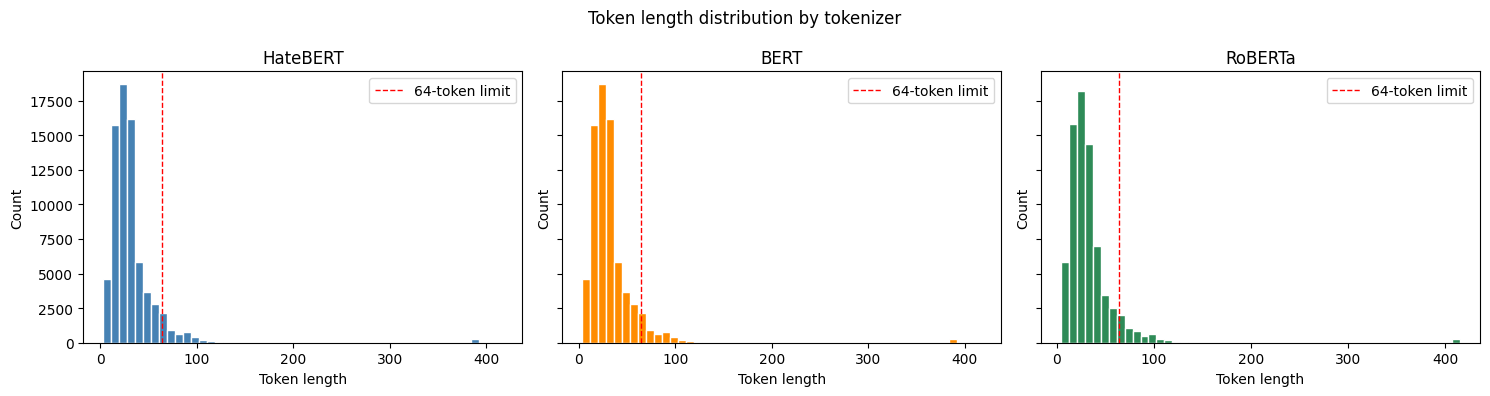

In [8]:
tokenizer_configs = {
    "HateBERT": "GroNLP/hateBERT",
    "BERT":     "bert-base-uncased",
    "RoBERTa":  "roberta-base",
}

# Go through all models
all_lengths = {}
for name, model_id in tokenizer_configs.items():
    # Load its tokenizer
    tok = AutoTokenizer.from_pretrained(model_id)
    # List all the chunks tokens lengths 
    lengths = [len(tok.encode(t, add_special_tokens=False)) for t in df["text"]]
    all_lengths[name] = lengths
    # Print different metrics on this list (mean length, variance, 95th percentile, ...)
    print(f"{name}:  mean={np.mean(lengths):.1f}  median={np.median(lengths):.1f}  "
          f"95th={np.percentile(lengths, 95):.1f}  max={max(lengths)}  "
          f">64 tokens: {sum(l > 64 for l in lengths)}")

# Plot the token length distributions for each model's tokenizer
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ["steelblue", "darkorange", "seagreen"]
for ax, (name, lengths), color in zip(axes, all_lengths.items(), colors):
    ax.hist(lengths, bins=50, color=color, edgecolor="white")
    ax.axvline(64, color="red", linestyle="--", linewidth=1, label="64-token limit")
    ax.set_title(name)
    ax.set_xlabel("Token length")
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Token length distribution by tokenizer")
plt.tight_layout()
plt.show()

### b. Filtering

**Remove entries with strictly more than `MAX_TOKENS` tokens.**  
We decide to use the **RoBERTa's tokenizer since it is the most conservative** (exlude sligthly more chunks)  
`chunk_id` is **reassigned** to stay contiguous.

In [9]:
MAX_TOKENS = 64

# Create a new column in the data frame containing the token's length from the RoBERTa tokenizer
df["token_length"] = all_lengths["RoBERTa"]

before = len(df)
#Provide an example of a too long entry
print("Example of a too long entry", df[df["token_length"] > MAX_TOKENS].iloc[0][["token_length", "text"]].to_dict())
# Filter the data frame, excluding all the entries having more than MAX_TOKENS tokens.
df = df[df["token_length"] <= MAX_TOKENS].drop(columns="token_length").reset_index(drop=True)
# Reassign the chunk_ids
df["chunk_id"] = range(len(df))

# Print the before vs. after result of the filtering
print(f"Chunks before filtering: {before:,}")
print(f"Chunks after filtering:  {len(df):,}  (removed {before - len(df)})")
df.head()

Example of a too long entry {'token_length': 94, 'text': '[hate] “Freedom IS more important than safety” these urine soaked socialist piece of shit fags never put a gun in their hands & fought 4 R country I have no problem wiping these high school commies off the face of R earth , or them killing eachother, & I’m glad they go home & play 10 hours of PlayStation it’ll prepares them 4 What’s coming 4 threatening R 1st & 2 Nd amendment'}
Chunks before filtering: 73,043
Chunks after filtering:  67,864  (removed 5179)


,chunk_id,text
0,0,[not hate] we need everyone to keep winning . ...
1,1,[not hate] : the hatred spewed by robert spenc...
2,2,[not hate] are antifa boomers ?
3,3,[not hate] #trucons aren't capable of anything...
4,4,[not hate] wow you really caught that . so ha...


## 6. Save

Save the chunks in a .csv file for the next step: index
Output: `chunks/chunks.csv` 
Schema: `chunk_id | text`

In [10]:
os.makedirs("chunks", exist_ok=True)
df.to_csv("chunks/chunks_training.csv", index=False)
print(f"Saved {len(df):,} chunks to chunks/chunks_training.csv")

Saved 67,864 chunks to chunks/chunks_training.csv
